# Cross-Source Searchlight Decoding: Accuracy Distribution

Load per-subject searchlight accuracy maps and visualize the distribution of whole-brain mean decoding accuracy across subjects for each cross-source comparison.

In [1]:
import os, glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

In [2]:
# ── Paths ──
output_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\searchlight_cross_source'
sub_dir = os.path.join(output_dir, 'per_subject')

subs = ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9',
        'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18',
        'Sub19', 'Sub20', 'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26',
        'Sub27', 'Sub28', 'Sub29', 'Sub30', 'Sub31']

cross_comparisons = [
    ('pleasant', 'neutral', 'pleasantAI', 'neutralAI'),
    ('pleasantAI', 'neutralAI', 'pleasant', 'neutral'),
    ('unpleasant', 'neutral', 'unpleasantAI', 'neutralAI'),
    ('unpleasantAI', 'neutralAI', 'unpleasant', 'neutral'),
]

comp_keys = [f"train_{c1}v{c2}_test_{c3}v{c4}" for c1, c2, c3, c4 in cross_comparisons]

## Load Per-Subject NIfTI Maps

In [3]:
# ── Read per-subject maps from saved NIfTI files ──
sub_means = {}  # comp -> list of per-subject whole-brain mean accuracy

for comp in comp_keys:
    means = []
    for sub in subs:
        fpath = os.path.join(sub_dir, f"{comp}_{sub}.nii.gz")
        if not os.path.exists(fpath):
            print(f"  Missing: {fpath}")
            means.append(np.nan)
            continue
        img = nib.load(fpath)
        acc_map = img.get_fdata()
        valid_vals = acc_map[~np.isnan(acc_map)]
        if len(valid_vals) == 0:
            print(f"  All NaN: {sub} | {comp}")
            means.append(np.nan)
        else:
            means.append(np.nanmean(valid_vals))
    sub_means[comp] = np.array(means)
    n_valid = np.sum(~np.isnan(sub_means[comp]))
    print(f"{comp}: {n_valid}/{len(subs)} subjects loaded, "
          f"mean={np.nanmean(sub_means[comp]):.4f}")

train_pleasantvneutral_test_pleasantAIvneutralAI: 30/30 subjects loaded, mean=0.0000
train_pleasantAIvneutralAI_test_pleasantvneutral: 30/30 subjects loaded, mean=0.0000
train_unpleasantvneutral_test_unpleasantAIvneutralAI: 30/30 subjects loaded, mean=0.0000
train_unpleasantAIvneutralAI_test_unpleasantvneutral: 30/30 subjects loaded, mean=0.0000


## Accuracy Distribution Plot

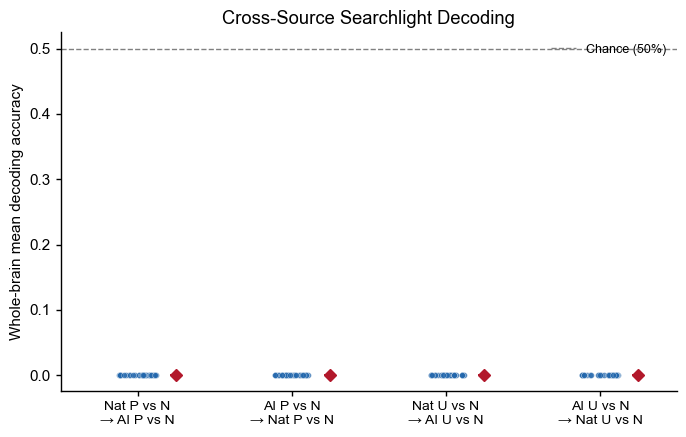

In [4]:
# ── Short labels ──
short_labels = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI':       'Nat P vs N\n\u2192 AI P vs N',
    'train_pleasantAIvneutralAI_test_pleasantvneutral':       'AI P vs N\n\u2192 Nat P vs N',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI':   'Nat U vs N\n\u2192 AI U vs N',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral':   'AI U vs N\n\u2192 Nat U vs N',
}

# ── Plot ──
mpl.rcParams.update({
    'font.size': 11, 'font.family': 'Arial',
    'axes.linewidth': 1, 'xtick.major.width': 1, 'ytick.major.width': 1
})

fig, ax = plt.subplots(figsize=(7, 4.5))

positions = np.arange(len(comp_keys))
data = [sub_means[c] for c in comp_keys]
labels = [short_labels.get(c, c) for c in comp_keys]

# Violin
parts = ax.violinplot(data, positions=positions,
                      showmeans=False, showmedians=False, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor('#7FB3D8')
    pc.set_edgecolor('none')
    pc.set_alpha(0.35)

# Individual subjects (jittered)
rng = np.random.default_rng(0)
for i, (pos, vals) in enumerate(zip(positions, data)):
    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(pos + jitter, vals, s=18, color='#2166AC',
              alpha=0.7, edgecolors='white', linewidths=0.3, zorder=3)
    # Group mean +/- SEM
    m = np.nanmean(vals)
    sem = np.nanstd(vals) / np.sqrt(np.sum(~np.isnan(vals)))
    ax.errorbar(pos + 0.25, m, yerr=sem, fmt='D', color='#B2182B',
                markersize=6, capsize=4, capthick=1.2, elinewidth=1.2, zorder=4)

ax.axhline(0.5, color='gray', ls='--', lw=1, zorder=1, label='Chance (50%)')
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Whole-brain mean decoding accuracy')
ax.set_title('Cross-Source Searchlight Decoding')
ax.legend(loc='upper right', frameon=False, fontsize=9)
ax.set_xlim(-0.5, len(comp_keys) - 0.5)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.savefig(os.path.join(output_dir, 'cross_source_accuracy_distribution.png'),
            dpi=300, bbox_inches='tight')
plt.show()

## Summary Statistics

In [5]:
print(f"{'Comparison':<60s} {'Mean':>6s} {'SEM':>6s} {'Min':>6s} {'Max':>6s}  {'t':>6s} {'p':>8s}")
print('-' * 100)
for c in comp_keys:
    vals = sub_means[c][~np.isnan(sub_means[c])]
    if len(vals) == 0:
        print(f"{c:<60s}   no valid data")
        continue
    m = vals.mean()
    sem = vals.std() / np.sqrt(len(vals))
    t_stat, p_val = stats.ttest_1samp(vals, 0.5)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    print(f"{c:<60s} {m:.4f} {sem:.4f} {vals.min():.4f} {vals.max():.4f} {t_stat:>6.2f} {p_val:>8.1e} {sig}")

Comparison                                                     Mean    SEM    Min    Max       t        p
----------------------------------------------------------------------------------------------------
train_pleasantvneutral_test_pleasantAIvneutralAI             0.0000 0.0000 0.0000 0.0000   -inf  0.0e+00 ***
train_pleasantAIvneutralAI_test_pleasantvneutral             0.0000 0.0000 0.0000 0.0000   -inf  0.0e+00 ***
train_unpleasantvneutral_test_unpleasantAIvneutralAI         0.0000 0.0000 0.0000 0.0000   -inf  0.0e+00 ***
train_unpleasantAIvneutralAI_test_unpleasantvneutral         0.0000 0.0000 0.0000 0.0000   -inf  0.0e+00 ***
